# Metoda linearne i nelinearne difuzije u uklanjanju šuma sa slike #
## student: Ivan Tomić ##
## mentor: Luka Grubišić, prof. dr. sc. ##
### 2. projektni zadatak ###
### kolegij: Inverzni problemi i strojni vid ###

# Uvod #

Digitalne slike često sadrže različite vrste šuma nastale tijekom akvizicije, prijenosa ili pohrane podataka. Šum može značajno smanjiti kvalitetu slike i otežati daljnju obradu, poput segmentacije, detekcije rubova ili medicinske dijagnostike. Zbog toga je uklanjanje šuma (engl. image denoising) jedno od temeljnih područja obrade slike. Jedan od važnih pristupa uklanjanju šuma temelji se na modeliranju slike kao kontinuirane funkcije i primjeni parcijalnih diferencijalnih jednadžbi koje postupno zaglađuju intenzitete piksela. Posebno su značajne metode difuzije, koje se mogu podijeliti na linearnu i nelinearnu difuziju.

Cilj ovog projekta je implementirati i usporediti metode linearne i nelinearne difuzije u uklanjanju šuma sa slike te analizirati njihov utjecaj na kvalitetu rekonstruirane slike. Poseban naglasak stavlja se na očuvanje rubova, budući da pretjerano zaglađivanje može dovesti do gubitka važnih strukturnih informacija.

# Problem uklanjanja šuma #

Promatrana slika može se modelirati kao:

$f(x, y) = u(x, y) + n(x, y)$

gdje je:
- $u(x, y)$ idealna (nepoznata) slika
- $n(x, y)$ šum
- $f(x, y)$ opažena, degradirana slika

Zadatak uklanjanja šuma sastoji se u procjeni originalne slike $u(x,y)$ na temelju dostupne degradirane slike $f(x,y)$.

Glavni je izazov, pritom, pronaći ravnotežu između uklanjanja šuma i očuvanja važnih pojedinosti i rubova slike. 
Naime, prejako izglađivanje uklonit će šum, ali i istovremeno uništiti fine strukture slike.

# Linearna difuzija #

Linearna difuzija temelji se na jednadžbi provođenja topline (heat equation):

$\frac{\partial u}{\partial t} = \Delta u$

pri čemu je:
- $u(x, y, t)$ slika tijekom procesa difuzije
- $\Delta$ Laplaceov operator
- $t$ umjestno vrijeme difuzije

Laplaceov operator opisuje lokalno izjednačavanje intenziteta između susjednih piksela. Intuitivno, svaki piksel poprima vrijednost bližu prosjeku svoje okoline, čime se smanjuju nagle oscilacije uzrokovane šumom.

Prednosti linearne difuzije jesu jednostavnost implementacije, numerička stabilnost za male korake te učinkovito uklanjanja visokofrekventnog šuma.

Glavni nedostatak je to što metoda ne razlikuje šum od stvarnih rubova slike što posljedično dovodi do zamućenja rubova, gubitka sitnih detalja te smanjenja oštrine slike, tj. dolazi do tzv. oversmoothing efekta.

# Nelinearna difuzija #

Kako bi se očuvali rubovi slike, razvijena je metoda nelinearne difuzije, najpoznatija u obliku Perona–Malik modela:

$\frac{\partial u}{\partial t} = \nabla \cdot ( g(|\nabla u|)\nabla u)$

gdje je $\nabla u$ gradijent slike, a $g(\cdot)$ funkcija difuzijskog koeficijenta. U ovom projektu koristimo se funkcijom:

$g(s) = \frac{1}{1 + (\frac{s}{\kappa})^2}$ pri čemu parametar $\kappa$ određuje osjetljivost metode na rubove.

Osnovna ideja: ako je gradijent mali, područje je homogeno pa se dopušta difuzija. Obratno je riječ vjerojatno o rubu, stoga se difuzija usporava ili zaustavlja.
Time se postiže uklanjanje šuma u ravnim područjima te očuvanje rubova i strukture slike.

Dakle, spomenimo da su prednosti nelinearne difuzije bolje očuvanje rubova, manji gubitak detalja te vizualno kvalitetniji rezultati.
S druge strane, za razliku od linearne difuzije, implementacija je složenija, parametri su osjetljiviji i moguća je numerička nestabilnost pri lošem odabiru parametara.


# Parametri algoritma #

Kao što smo spomenuli gore, za kvalitetan rezultat vrlo je važan dobar izbor parametara difuzije. Imamo sljedeće parametre:

1. broj iteracija
- određuje koliko dugo traje proces difuzije
- malen broj iteracija nedovoljno uklanja šum
- prevelik broj iteracija dat će pretjerano zaglađivanje (izgubit će se rubovi).

2. parametar $dt$
- predstavlja veličinu vremenskog koraka: $u^{k+1} = u^k + dt \cdot F(u^k)$
- veće vrijednosti dovode do bržeg zaglađivanja, mogućeg gubitka detalja te potencijalne numeričke nestabilnosti
- manje vrijednosti osiguravaju stabilnije rezultate i sporiju konvergenciju

3. parametar $\kappa$
- kod nelinearne difuzije određuje prag osjetljivosti na rubove
- manje vrijednosti štite rubove ostavljajući više šuma
- veće vrijednosti uklanjaju šum, ali povećavaju rizik zamućenja (u slučaju prevelikog $\kappa$, nelinearna difuzija ponaša se slično kao i linearna difuzija)

# Evaluacija kvalitete #

Za usporedbu metoda koriste se objektivne metrike kvalitete slike.

PSNR (Peak Signal-to-Noise Ratio) mjeri omjer korisnog signala i šuma:

$PSNR = 10 \log _{10}(\frac{MAX^2}{MSE})$

Veće vrijednosti PSNR-a označavaju bolju rekonstrukciju.

Imamo i SSIM (Structural Similarity Index) koji mjeri sličnost strukture između originalne i rekonstruirane slike s vrijednostima u intervalu $[0, 1]$ pri čemu je $1$ ako se slike savršeno podudaraju.

Iz svega navedenog očekujemo da bi nelinearna difuzija trebala dati bolje rezultate u smislu da bi slika trebala biti bliža stvarnoj (odnosno veća vrijednost SSIM-a).

Eksperimentalna usporedba omogućit će procjenu kompromisa između uklanjanja šuma i očuvanja vizualne kvalitete slike.

# Implementacija #

Za eksperimentalni dio projekta implementirane su metode linearne i nelinearne difuzije u programskom jeziku Python, koristeći biblioteke za numeričko računanje i obradu slike. Cilj implementacije bio je simulirati proces uklanjanja šuma sa slike te usporediti učinkovitost obje metode.

Najprije učitamo potrebne biblioteke:

In [114]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import laplace
from skimage import data, img_as_float
from skimage.util import random_noise
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

Kao ulaznu sliku upotrijebit ćemo standardnu testnu crno-bijelu sliku camera, dostupnu unutar biblioteke scikit-image. Slika je normalizirana u raspon vrijednosti [0,1], što olakšava numeričku stabilnost tijekom difuzije.

Na originalnu sliku dodajemo Gaussov šum (Gaussian noise) kako bi se simulirala degradirana slika koju je potrebno rekonstruirati. Varijancu šuma `var` postavljamo na $0.01$ što je dovoljno izražen šum za usporedbu metoda.

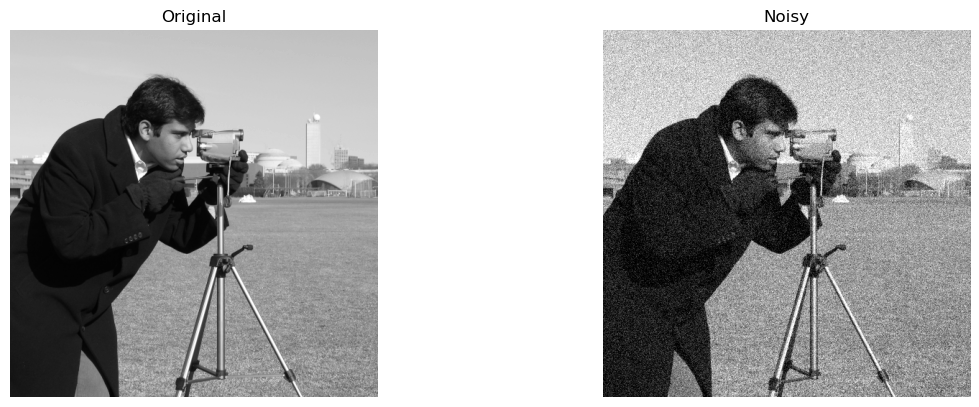

In [115]:
original = img_as_float(data.camera())

# Gaussova šum
noisy = random_noise(
    original,
    mode='gaussian',
    var=0.01
)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(original, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(noisy, cmap='gray')
plt.title("Noisy")
plt.axis('off')

plt.tight_layout()
plt.show()


Sada možemo prijeći na linearnu difuziju. Laplaceov operator izračunat je pomoću funkcije `laplace()` iz biblioteke `SciPy`.

U svakoj iteraciji pikseli se prilagođavaju prosječnoj vrijednosti svoje okoline, čime se postupno smanjuje visokofrekventni šum.

Kao što rekli u teorijskom dijelu, veći broj iteracija ili veći $dt$ dovode do jačeg izglađivanja slike.

In [116]:
def linear_diffusion(image, iterations=50, dt=0.1):
    u = image.copy()

    for _ in range(iterations):
        u = u + dt * laplace(u)

    return u

Na sličan način, implementiramo i nelinearnu difuziju koristeći se Perona-Malik modelom.

In [117]:
def nonlinear_diffusion(image, iterations=50, dt=0.15, kappa=20):
    u = image.copy()

    for _ in range(iterations):

        # gradijenti
        ux = np.roll(u, -1, axis=1) - u
        uy = np.roll(u, -1, axis=0) - u

        # Perona-Malik 
        cx = 1 / (1 + (ux / kappa)**2)
        cy = 1 / (1 + (uy / kappa)**2)

        # divergencija difuzijskog toka
        div_x = cx * ux - np.roll(cx * ux, 1, axis=1)
        div_y = cy * uy - np.roll(cy * uy, 1, axis=0)

        u = u + dt * (div_x + div_y)

    return u

Trebamo još gorespomenute metrike PSNR i SSIM za procjenu kvalitete slike.

In [118]:
def evaluate(reference, image, name):
    psnr = peak_signal_noise_ratio(reference, image)
    ssim = structural_similarity(reference, image, data_range=1.0)

    print(f"{name}")
    print(f"PSNR: {psnr:.3f}")
    print(f"SSIM: {ssim:.3f}")
    print()

# Rezultati #

Najprije ćemo promotriti kako se algoritam ponaša ako mijenjamo broj iteracija. Spremit ćemo pet različitih vrijednosti iteracija u listu `iteration_list`. Očekujemo da će za medijan među vrijednostima liste nelinearna difuzija biti bolja od linearne. Pritom fiksiramo vrijednost parametra $dt$ na 0.1, a vrijednost parametra $\kappa$ na 0.1.

broj iteracija = 10

Linear diffusion
PSNR: 26.622
SSIM: 0.686

Nonlinear diffusion
PSNR: 27.370
SSIM: 0.622



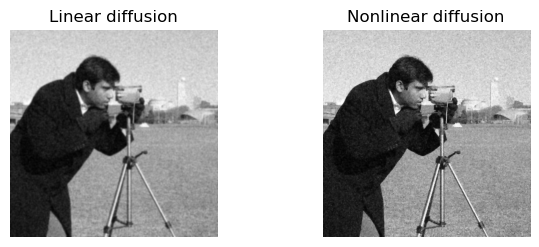

broj iteracija = 20

Linear diffusion
PSNR: 25.452
SSIM: 0.693

Nonlinear diffusion
PSNR: 28.137
SSIM: 0.727



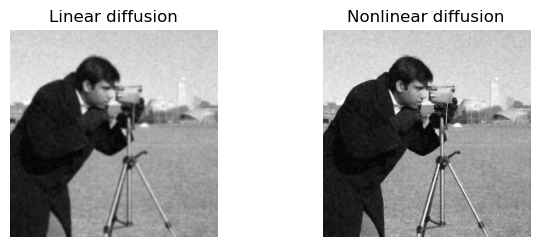

broj iteracija = 50

Linear diffusion
PSNR: 23.768
SSIM: 0.660

Nonlinear diffusion
PSNR: 26.279
SSIM: 0.704



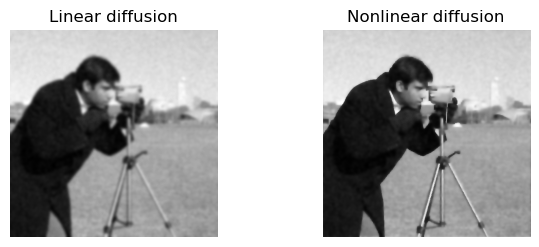

broj iteracija = 100

Linear diffusion
PSNR: 22.654
SSIM: 0.627

Nonlinear diffusion
PSNR: 24.345
SSIM: 0.658



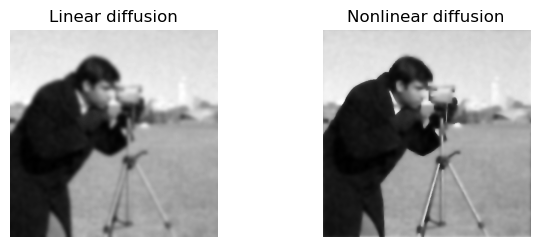

broj iteracija = 500

Linear diffusion
PSNR: 20.478
SSIM: 0.575

Nonlinear diffusion
PSNR: 20.456
SSIM: 0.569



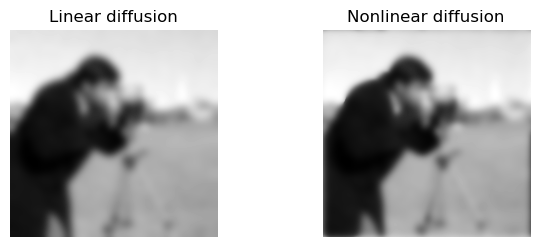

In [119]:
iterations_list = [10, 20, 50, 100, 500]

for i in iterations_list:
    linear_result = linear_diffusion(
        noisy,
        iterations = i,
        dt = 0.1
    )

    nonlinear_result = nonlinear_diffusion(
        noisy,
        iterations = i,
        dt = 0.1,
        kappa = 0.1
    )

    print(f"broj iteracija = {i}")
    print()

    evaluate(original, linear_result, "Linear diffusion")
    evaluate(original, nonlinear_result, "Nonlinear diffusion")

    plt.subplot(2, 2, 3)
    plt.imshow(linear_result, cmap='gray')
    plt.title("Linear diffusion")
    plt.axis('off')

    plt.subplot(2, 2, 4)
    plt.imshow(nonlinear_result, cmap='gray')
    plt.title(f"Nonlinear diffusion")
    plt.axis('off')

    

    plt.tight_layout()
    plt.show()

    


Kao što smo i napisali u teorijskom dijelu, čim uzmemo previše ili premalo iteracija, nelinearna difuzija daje lošije rezultate od linearne. 

Promotrimo sada mijenjanje parametra $dt$. Ovaj put uzet ćemo 7 različitih vrijednosti i spremiti ih u pripadnu listu `dt_list` pri čemu smo parametre $\kappa$ i broj iteracija fiksirali na $0.1$, odnosno $50$.

dt = 0.01

Linear diffusion
PSNR: 27.211
SSIM: 0.624

Nonlinear diffusion
PSNR: 24.467
SSIM: 0.450



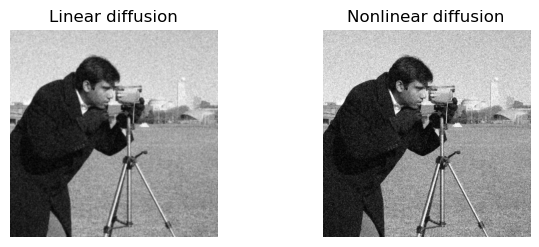

dt = 0.05

Linear diffusion
PSNR: 25.059
SSIM: 0.689

Nonlinear diffusion
PSNR: 27.829
SSIM: 0.729



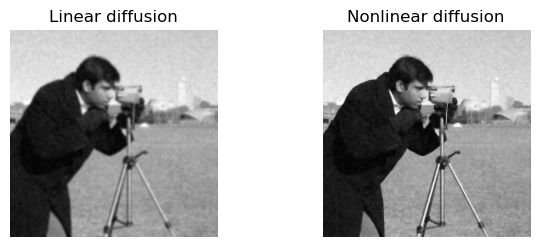

dt = 0.1

Linear diffusion
PSNR: 23.768
SSIM: 0.660

Nonlinear diffusion
PSNR: 26.279
SSIM: 0.704



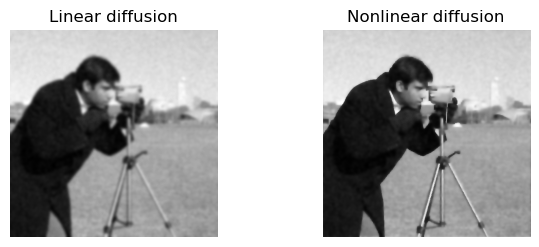

dt = 0.15

Linear diffusion
PSNR: 23.089
SSIM: 0.640

Nonlinear diffusion
PSNR: 25.180
SSIM: 0.678



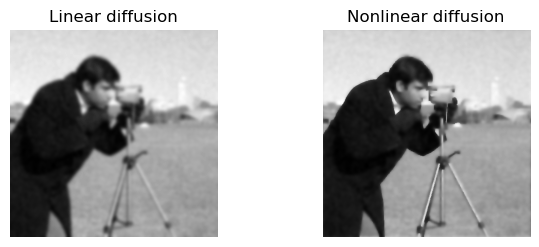

dt = 0.25

Linear diffusion
PSNR: 22.298
SSIM: 0.604

Nonlinear diffusion
PSNR: 23.694
SSIM: 0.642



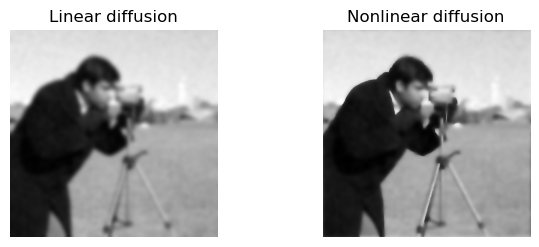

dt = 0.26

Linear diffusion
PSNR: 11.593
SSIM: 0.060

Nonlinear diffusion
PSNR: 23.576
SSIM: 0.635



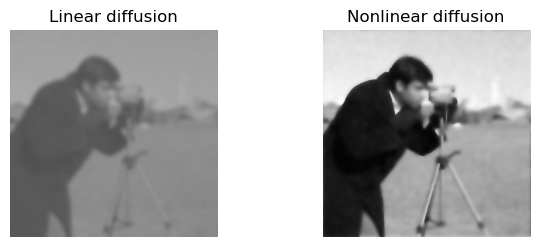

dt = 0.4

Linear diffusion
PSNR: -298.265
SSIM: -0.000

Nonlinear diffusion
PSNR: 21.910
SSIM: 0.332



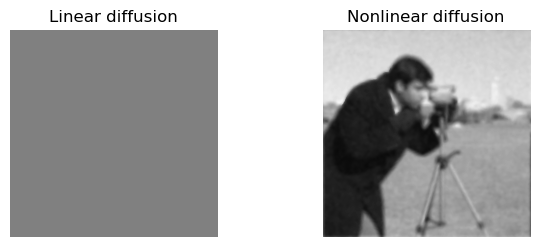

In [120]:
dt_list = [0.01, 0.05, 0.1, 0.15, 0.25, 0.26, 0.4]

for i in dt_list:
    linear_result = linear_diffusion(
        noisy,
        iterations = 50,
        dt = i
    )

    nonlinear_result = nonlinear_diffusion(
        noisy,
        iterations = 50,
        dt = i,
        kappa = 0.1
    )

    print(f"dt = {i}")
    print()
    
    evaluate(original, linear_result, "Linear diffusion")
    evaluate(original, nonlinear_result, "Nonlinear diffusion")

    plt.subplot(2, 2, 3)
    plt.imshow(linear_result, cmap='gray')
    plt.title("Linear diffusion")
    plt.axis('off')

    plt.subplot(2, 2, 4)
    plt.imshow(nonlinear_result, cmap='gray')
    plt.title(f"Nonlinear diffusion")
    plt.axis('off')

    

    plt.tight_layout()
    plt.show()

Zanimljiva stvar koju ovdje vidimo jest da se linearna difuzija "urušava" za $dt > 0.25$,, štoviše PSNR poprima negativne vrijednosti. Svakako primjećujemo da nelinearna difuzija daje bolje rezultate za veći $dt$, ali najbolje za opet medijan, tj. $0.1$. 

Linear diffusion
PSNR: 23.768
SSIM: 0.660

kappa = 0.01

Nonlinear diffusion
PSNR: 21.188
SSIM: 0.320



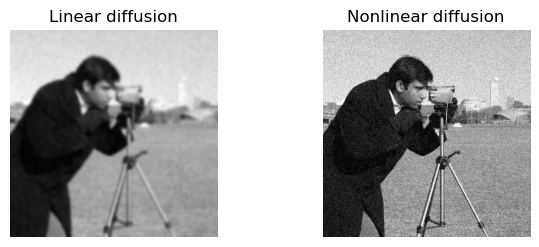

kappa = 0.05

Nonlinear diffusion
PSNR: 28.099
SSIM: 0.743



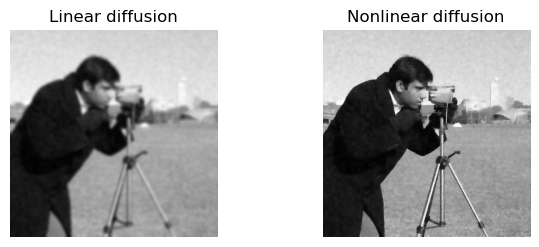

kappa = 0.1

Nonlinear diffusion
PSNR: 26.279
SSIM: 0.704



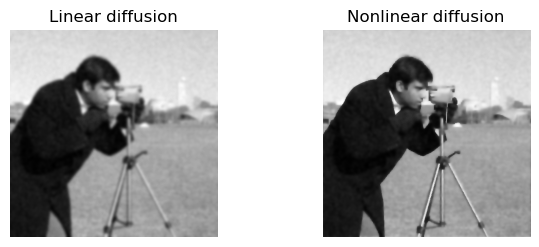

kappa = 0.5

Nonlinear diffusion
PSNR: 23.517
SSIM: 0.654



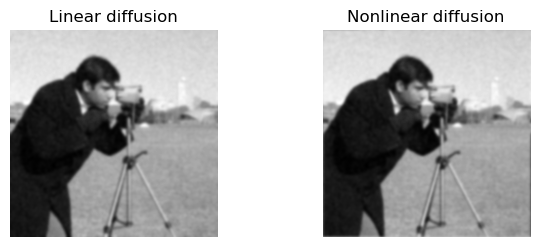

kappa = 2

Nonlinear diffusion
PSNR: 23.434
SSIM: 0.653



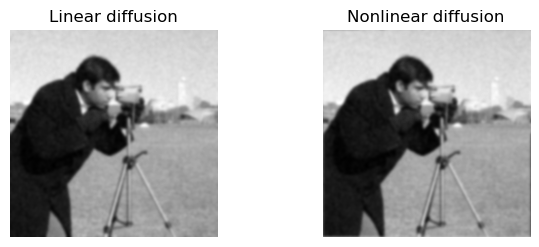

In [121]:
kappa_list = [0.01, 0.05, 0.1, 0.5, 2]

linear_result = linear_diffusion(
        noisy,
        iterations = 50,
        dt = 0.1
    )



evaluate(original, linear_result, "Linear diffusion")

for i in kappa_list:
    print(f"kappa = {i}")
    print()

    nonlinear_result = nonlinear_diffusion(
        noisy,
        iterations = 50,
        dt = 0.1,
        kappa = i
    )

    
    evaluate(original, nonlinear_result, "Nonlinear diffusion")

    plt.subplot(2, 2, 3)
    plt.imshow(linear_result, cmap='gray')
    plt.title("Linear diffusion")
    plt.axis('off')

    plt.subplot(2, 2, 4)
    plt.imshow(nonlinear_result, cmap='gray')
    plt.title(f"Nonlinear diffusion")
    plt.axis('off')

    

    plt.tight_layout()
    plt.show()

Primjećujemo da najbolje rezultate nelinearne difuzije dobivamo za $\kappa = 0.05$. Za veće vrijednost, vrijednost SSIM-a lagano se smanjuje dok naglo poraste između $0.01$ i $0.05$. Parametar $\kappa$, dakako, ne utječe na linearnu difuziju.


# Zaključak # 

Metode difuzije predstavljaju važan alat u obradi slike. Linearna difuzija pruža jednostavno i učinkovito uklanjanje šuma, ali često uz gubitak detalja. Nelinearna difuzija uvodi adaptivni mehanizam koji omogućuje očuvanje rubova te u mnogim slučajevima daje kvalitetnije rezultate uz dobru uporabu parametara. U ovom projektu analizirali smo obje metode na istim ulaznim podacima kako bi se usporedila njihova učinkovitost i prikladnost za zadatak uklanjanja šuma sa slike. Testiranjem za različite vrijednosti parametra, zaključujemo da je nelinearna difuzija bolja od linearne difuzije kada je broj iteracija u rasponu od $20$ do $100$ i kad je vrijednost parametra $dt$ oko 0.1 ili veća. Zapravo, za veću vrijednost tog parametra nelinearna difuzija i dalje daje dobre rezultate dok se linearna difuzija "ruši" na više od $0.25$. Također, pokazalo se da je vrijednost $\kappa$ dobro uzeti između $0.05$ i $0.1$. Iz svega danog, možemo izvesti zaključak da je linearna difuzija na neki način stabilnija (osim u slučaju promjene $dt$), ali da će nelinearna difuzija postići bolje rezultate ako uzmemo "dobre" vrijednosti za dane parametre.